# Neighborhoods, embeddings, neural collapse

In [1]:
from sklearn.datasets import make_blobs
import numpy as np

centers = np.array(
    [
        [1, 1],
        [1, -1],
        [-1, -1],
        [-1, 1],
        [0,0],
    ]
)

X, y = make_blobs(
    n_samples=1000,
    centers=centers,
    n_features=5,
    cluster_std=0.7,
    random_state=42,
)

print(X.shape, y.shape)

(1000, 2) (1000,)


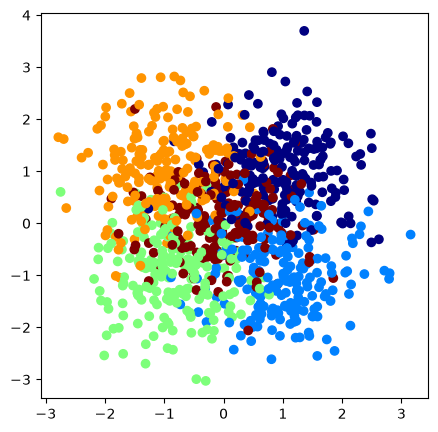

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='jet')
plt.show()

Importantly, we see that our blobs "sort of" overlap by controlling cluster_std. We can actually change their hard labels for a pertinence value, which is calculated using the distance to each centroid (with enough cluster_std, we can actually make items have higher pertinence to a different cluster than the original one...):

In [3]:
from sklearn.metrics import pairwise_distances

def calculate_pertinences(
    x : np.ndarray,
    c : np.ndarray,
):
    dist = pairwise_distances(x, c, metric="euclidean")
    pert = 1/dist
    pert /= pert.sum(axis=1, keepdims=True)
    return pert
    

In [5]:
pert = calculate_pertinences(X, centers)
pert.shape

(1000, 5)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, p_train, p_test = train_test_split(
    X,
    y,
    pert,
    test_size=0.2,
    random_state=42,
)

In [7]:
import torch 

x_tensor = torch.tensor(X_train).float()
y_tensor = torch.tensor(y_train)
p_tensor = torch.tensor(p_train).float()

print(x_tensor.shape, y_tensor.shape, p_tensor.shape)

torch.Size([800, 2]) torch.Size([800]) torch.Size([800, 5])


## Baseline: train with a hard class (y)

In [43]:
from mlxp import models
from mlxp import training

clf = models.MLP(
    input_dim = 2,
    hidden_dim = 100,
    output_dim = 5,
    n_layers = 20,
    dropout = 0.0,
    block_type = "simple" # "simple" or "residual"
)

print(clf)

MLP(
  (input_layer): Linear(in_features=2, out_features=100, bias=True)
  (input_batch_norm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (hidden_layers): ModuleList(
    (0-19): 20 x SimpleBlock(
      (linear): Linear(in_features=100, out_features=100, bias=True)
      (batch_norm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU()
      (dropout): Identity()
    )
  )
  (output_layer): Linear(in_features=100, out_features=5, bias=True)
)


In [44]:
import torch.nn as nn

train_data = training.train_mlp(
    model=clf,
    x=x_tensor,
    y=y_tensor,
    p=p_tensor,
    optimizer_type="adam",
    device='cuda:0',
    batch_size=500,
    val_split=0.2,
    epochs=1000,
    seed=42,
    weight_decay=5e-4,
    loss_fn=nn.CrossEntropyLoss(),
    patience=1000000,
    verbose=True,
    lr=1e-3,
    task="classification",
    record_nc=True,
)

epoch 1/1000 - train_loss: 1.6912 - val_loss: 1.6100 - train_acc: 0.2000 - val_acc: 0.2188
epoch 2/1000 - train_loss: 1.6605 - val_loss: 1.6100 - train_acc: 0.2040 - val_acc: 0.2188
epoch 3/1000 - train_loss: 1.6298 - val_loss: 1.6100 - train_acc: 0.2600 - val_acc: 0.2188
epoch 4/1000 - train_loss: 1.6130 - val_loss: 1.6101 - train_acc: 0.2840 - val_acc: 0.2188
epoch 5/1000 - train_loss: 1.5852 - val_loss: 1.6103 - train_acc: 0.3540 - val_acc: 0.2188
epoch 6/1000 - train_loss: 1.5629 - val_loss: 1.6103 - train_acc: 0.4180 - val_acc: 0.2188
epoch 7/1000 - train_loss: 1.5414 - val_loss: 1.6105 - train_acc: 0.4820 - val_acc: 0.2188
epoch 8/1000 - train_loss: 1.5195 - val_loss: 1.6107 - train_acc: 0.5340 - val_acc: 0.2188
epoch 9/1000 - train_loss: 1.4956 - val_loss: 1.6110 - train_acc: 0.5860 - val_acc: 0.2188
epoch 10/1000 - train_loss: 1.4819 - val_loss: 1.6116 - train_acc: 0.6100 - val_acc: 0.1938
epoch 11/1000 - train_loss: 1.4736 - val_loss: 1.6124 - train_acc: 0.6380 - val_acc: 0.19

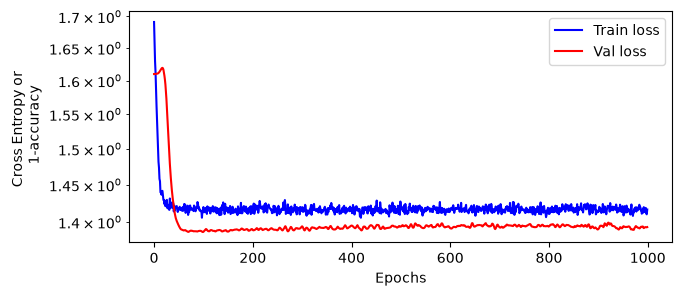

In [45]:
import matplotlib.pyplot as plt 
import numpy as np 

plt.figure(figsize=(7,3))
plt.plot(train_data['train_loss'], 'b', label='Train loss')
plt.plot(train_data['val_loss'], 'r', label='Val loss')
#plt.plot(1-np.array(train_data['train_acc']), 'b:', label='Train error rate')
#plt.plot(1-np.array(train_data['val_acc']), 'r:', label='Val error rate')
#plt.plot(train_data['train_nc1'], 'b--', label='Train NC1')
#plt.plot(train_data['val_nc1'], 'r--', label='Val NC1')
plt.ylabel('Cross Entropy or \n 1-accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.semilogy()
plt.show()

In [46]:
from mlxp.models import get_embeddings

z = get_embeddings(model=clf, x=x_tensor)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pca_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2)),
    ]
)

z_pca = pca_pipeline.fit_transform(z.detach().cpu().numpy())

z_pca = PCA(n_components=2).fit_transform(
    z.detach().cpu().numpy()
)

#z_pca

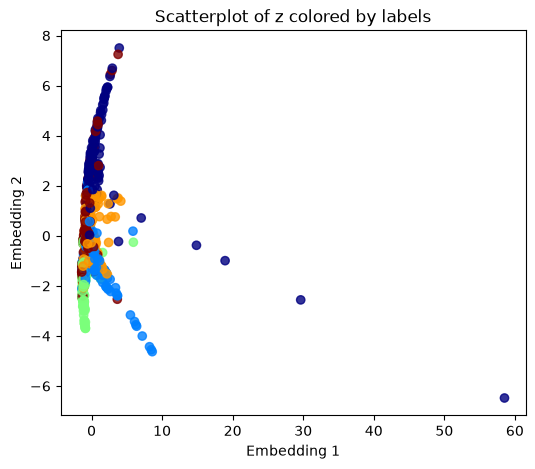

In [48]:


plt.figure(figsize=(6, 5))


plt.scatter(
    z_pca[:, 0],
    z_pca[:, 1],
    c=y_tensor.detach().cpu().numpy(),
    cmap="viridis",
    alpha=0.8,
)

plt.gca().collections[0].set_cmap(plt.colormaps["jet"].resampled(5))
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")
plt.title("Scatterplot of z colored by labels")
#plt.legend(label="Label")
plt.show()